In [1]:
'''
suggestions from CW:
--------------------
Funky matching / bad peak timing: matches with strange templates?
- quick check with vis — make a DARTsortAnalysis object on the KS spike train and the recording that templates were learned from
- use dartsort.vis.make_unit_summary() to check out those units
--> If it’s just a few bad eggs entering the matcher, maybe there’s an easy way to get rid of them?

Duplicate spikes / thresholds / RP violations: here are a few tools for this.

For RP violations specifically, two tools:
- MatchingConfig has a refractory_radius_frames parameter which is 0 by default
--> conservatively set it to 10, or you can be more aggressive
- also a dartsort.deduplicate_spikes() function which can do this after the fact, with a parameter in ms
--> This would let spikes match with their best template down to the threshold and then exclude events later
--> slightly different from using a radius during the matching.

Main threshold parameter of the matching config is low by default
- could raise it — really nice units usually have score values >20
- could look at the units/inspect a histogram of their matching scores
--> if sorting = dartsort.match(…), then plt.hist(sorting.scores[sorting.labels == unit_id]) and see how it looks
**NOTE: might need to np.sqrt() the scores, they’re in squared units internally** 

Amplitudes
- in the matching configuration, amplitude scaling is controlled by the parameters:
-- amplitude_scaling_variance
-- amplitude_scaling_boundary
--> regularize the amount of scaling and also impose hard limits

What to make of the amplitudes view in the visualization? What causes that pile of amplitudes for t~1500?
- seems to align with stim periods/concatenation boundaries
- z-scoring with hash/stim artifact?
- preprocessing difference across chunks?
- something else??
'''
# todo maybe don't need all of these things
import numpy as np
import pandas as pd
import os 
import sys

import preprocess.spikesort_utils as sort_utils
sys.path.append("..//neural")
from format_waveform_data import map_contacts_to_intan
sys.path.append("..//utils")
import load_matlab_data

import spikeinterface.full as si
from probeinterface import get_probe
import dartsort

import probeinterface.plotting as prb_plotting
import spikeinterface.widgets as sw
import dartsort.vis as dartvis
import matplotlib.pyplot as plt

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\clustering\mixture.py:108: UserWarning: Your PyTorch version (2.5.1+cu121) is supported by dartsort, but dartsort would be faster if you had >= 2.6.0.
  warnings.warn(


In [2]:
''' file paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "SLV132"
session_id = "250310"
ephys_id = "SLV132_250310_122522"

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# kilosort and dartsort outputs live here
ks_folder = f"{intan_folder}stim_processing/remove_frames/kilosort_si/"
ds_folder = f"{intan_folder}stim_processing/remove_frames/dartsort/"

# for saving figures
save_folder = f"{intan_folder}stim_processing/remove_frames/figs/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)

save folder exists


In [4]:
# pre stim recording chunks
rec_pre_stim = si.load(f"{ds_folder}pre_stim_binary")

In [7]:
print(rec_pre_stim)
print(rec_pre_stim.get_num_channels())
print(rec_pre_stim.get_num_frames())
print(rec_pre_stim.get_sampling_frequency())
print(rec_pre_stim.get_probe())
print(rec_pre_stim.get_property_keys())

BinaryFolderRecording: 58 channels - 30.0kHz - 1 segments - 81,607,968 samples 
                       2,720.27s (45.34 minutes) - float32 dtype - 17.63 GiB
58
81607968
30000.0
Probe - 58ch - 2shanks
['gain_to_uV', 'offset_to_uV', 'contact_vector', 'location', 'group', 'channel_name', 'gain_to_physical_unit', 'group_names', 'offset_to_physical_unit', 'physical_unit']


In [34]:
# load the ks outputs as a dartsort object
ks_st = sort_utils.load_ks4_sorting(rec_pre_stim, f"{ks_folder}/sorter_output/")

# realign the spike times + get templates
realign_ms = 1.5
template_cfg = dartsort.TemplateConfig(whitening=dartsort.WhiteningConfig(strategy='none'))
pre_stim_st, template_data = dartsort.estimate_template_library(
    recording=rec_pre_stim,
    sorting=ks_st,
    realign_cfg=dartsort.TemplateRealignmentConfig(realign_shift_ms=realign_ms),
    template_cfg=template_cfg,
    template_npz_path=f"{ds_folder}/template_data.npz",
)

Raw templates:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2721 [00:00<?, ?it/s]

Raw templates:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2721 [00:00<?, ?it/s]

Templates:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2721 [00:00<?, ?it/s]

Medians:cuda:4:   0%|          | 0/293 [00:00<?, ?it/s]

In [35]:
# get the cluster assignments (good etc)
clu_group = sort_utils.get_ks_cluster_groups(f"{ks_folder}")

In [36]:
dsa = dartsort.DARTsortAnalysis.from_sorting(sorting=pre_stim_st, template_data=template_data, recording=rec_pre_stim)

In [37]:
n_clusters = len(clu_group)
good_cell_idx = np.asarray([])
for i in range(n_clusters):
    if clu_group[i] == 'good':
        good_cell_idx = np.append(good_cell_idx, i)

In [38]:
good_cell_idx

array([  0.,   8.,  10.,  11.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,
        21.,  22.,  23.,  24.,  27.,  35.,  39.,  49.,  54.,  55.,  56.,
        57.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  74.,  75.,  76.,
        80.,  82.,  83.,  84.,  86.,  87.,  88.,  92., 102., 104., 106.,
       107., 109., 110., 111., 113., 114., 117., 118., 119., 123., 126.,
       130., 133., 134., 135., 138., 144., 145., 146., 147., 149., 150.,
       151., 152., 153., 154., 155., 157., 159., 166., 168., 170., 172.,
       176., 178., 179., 180., 181., 182., 183., 186., 187., 188., 189.,
       190., 191., 192., 193., 194., 195., 196., 197., 198., 199., 200.,
       201., 202., 204., 207., 208., 210., 212., 213., 214., 216., 217.,
       218., 220., 221., 222., 226., 229., 230., 235., 236., 237., 238.,
       240., 244., 245., 246., 255., 261., 267., 270., 277., 282., 283.,
       285., 286., 287., 288.])

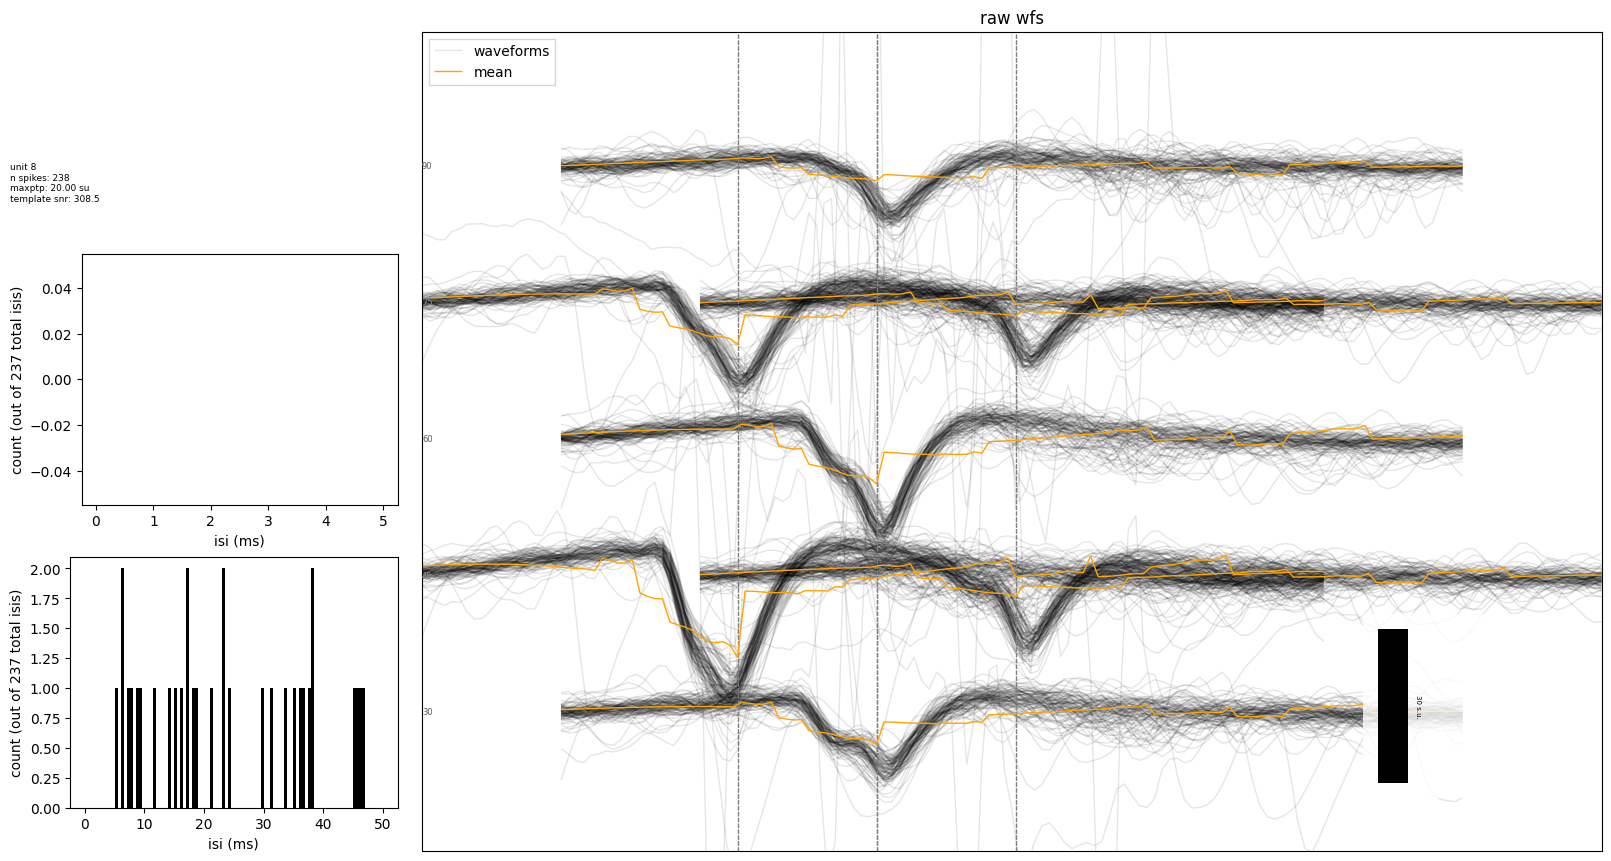

In [41]:
# visualize single units
dartvis.make_unit_summary(dsa, 8, 
                          plots=(dartvis.unit.UnitTextInfo(), 
                                 dartvis.ISIHistogram(), 
                                 dartvis.ISIHistogram(0.5, 50.0), 
                                 dartvis.RawWaveformPlot(color_by=None)));